# Ensemble Modeller
**Kutay Kalay** · SoftITo Yapay Zeka · 23.09.2026

Tek bir karar ağacı ile 6 ensemble modeli German Credit verisinde karşılaştırıyoruz.
- **Bagging** (paralel ağaçlar + oylama): Random Forest
- **Boosting** (sıralı ağaçlar, her biri öncekinin hatasını düzeltir): AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [2]:
import re
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Veri
German Credit: 1000 kredi başvurusu, hedef riskli (1) ya da iyi (0).
XGBoost ve LightGBM sütun adlarında `<`, `[`, `:` gibi karakterlere izin vermediği için one-hot sonrası sütun adlarını sadeleştiriyoruz.

In [5]:
df = fetch_openml("credit-g", version=1, as_frame=True).frame.copy()
df["riskli"] = (df["class"] == "bad").astype(int)
df = df.drop(columns="class")

kategorik = list(df.select_dtypes(include=["category", "object"]).columns)
X = pd.get_dummies(df.drop(columns="riskli"), columns=kategorik, drop_first=True, dtype=int)
X.columns = [re.sub(r"[^0-9a-zA-Z_]+", "_", c) for c in X.columns]
assert X.columns.is_unique
y = df["riskli"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Eğitim:", X_tr.shape, "Test:", X_te.shape)

Eğitim: (800, 48) Test: (200, 48)


## 2. Neden tek ağaç yetmiyor?
Derinliği sınırsız bir karar ağacı eğitim verisini **ezberler**: eğitimde %100 başarı, testte ise çok daha düşük.
Ensemble yöntemleri, birçok ağacı birleştirerek bu kararsızlığı azaltır.

In [6]:
for derinlik in [None, 3]:
    agac = DecisionTreeClassifier(max_depth=derinlik, random_state=SEED).fit(X_tr, y_tr)
    print(f"max_depth={derinlik}: eğitim = {agac.score(X_tr, y_tr):.3f} | test = {agac.score(X_te, y_te):.3f}")

max_depth=None: eğitim = 1.000 | test = 0.655
max_depth=3: eğitim = 0.723 | test = 0.680


## 3. Modeller
Hepsi aynı veride, aynı 5 katlı CV ile ölçülüyor. Üç şeye bakıyoruz:
- **CV doğruluğu** ve **CV ROC-AUC** (ortalama ± std)
- **Test ROC-AUC**
- **Süre** (saniye)

In [7]:
modeller = {
    "Karar ağacı": DecisionTreeClassifier(max_depth=4, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, eval_metric="logloss", random_state=SEED),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=SEED, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=SEED, verbose=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
satirlar = []
for ad, model in modeller.items():
    t0 = time.time()
    cvs = cross_validate(model, X_tr, y_tr, cv=cv, scoring=["accuracy", "roc_auc"])
    model.fit(X_tr, y_tr)
    olasilik = model.predict_proba(X_te)[:, 1]
    satirlar.append({
        "model": ad,
        "cv_accuracy": cvs["test_accuracy"].mean(),
        "cv_auc": cvs["test_roc_auc"].mean(),
        "cv_auc_std": cvs["test_roc_auc"].std(),
        "test_accuracy": accuracy_score(y_te, (olasilik >= 0.5).astype(int)),
        "test_auc": roc_auc_score(y_te, olasilik),
        "sure_sn": time.time() - t0,
    })
    print(f"{ad:18s} bitti")

tablo = pd.DataFrame(satirlar).set_index("model").sort_values("cv_auc", ascending=False)
tablo.round(3)

Karar ağacı        bitti
Random Forest      bitti
AdaBoost           bitti
Gradient Boosting  bitti
XGBoost            bitti
LightGBM           bitti
CatBoost           bitti


,cv_accuracy,cv_auc,cv_auc_std,test_accuracy,test_auc,sure_sn
model,,,,,,
CatBoost,0.768,0.797,0.035,0.780,0.820,2.706
Random Forest,0.751,0.794,0.039,0.765,0.798,8.303
XGBoost,0.764,0.789,0.039,0.760,0.781,1.294
Gradient Boosting,0.751,0.789,0.038,0.785,0.798,5.078
LightGBM,0.758,0.779,0.041,0.765,0.781,0.771
AdaBoost,0.699,0.743,0.041,0.715,0.766,6.807
Karar ağacı,0.700,0.711,0.058,0.650,0.670,0.095


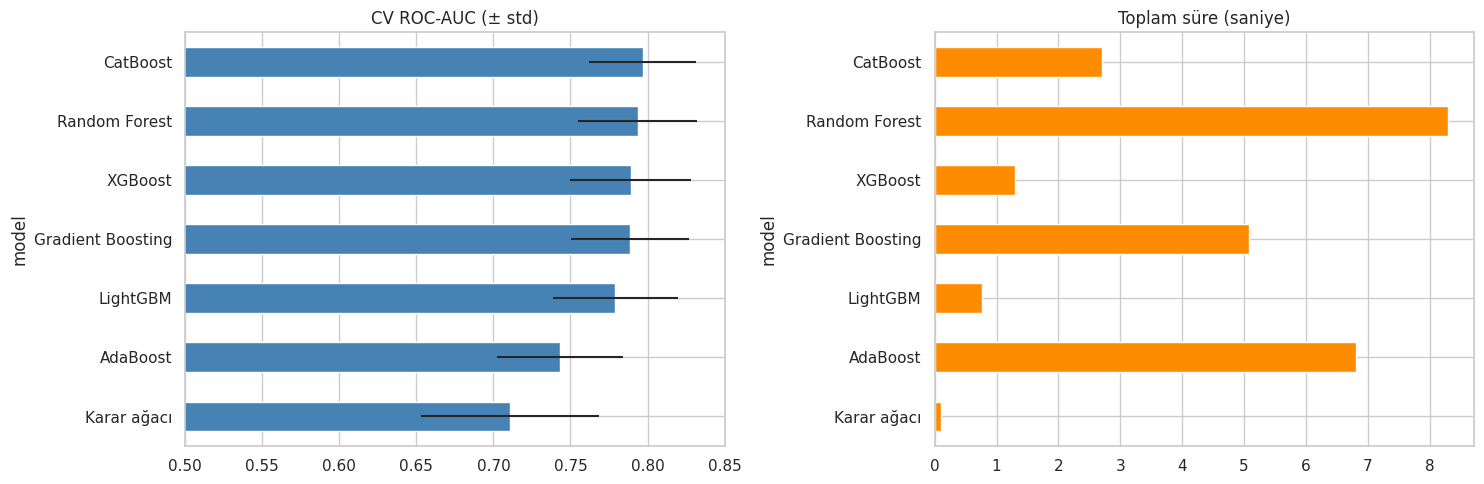

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tablo["cv_auc"].plot(kind="barh", xerr=tablo["cv_auc_std"], ax=axes[0], color="steelblue")
axes[0].set(title="CV ROC-AUC (± std)", xlim=(0.5, 0.85))
axes[0].invert_yaxis()
tablo["sure_sn"].plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set(title="Toplam süre (saniye)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Hangi değişkenler önemli?
Ağaç tabanlı modeller, her değişkenin kararlara ne kadar katkı yaptığını (`feature_importances_`) verir.

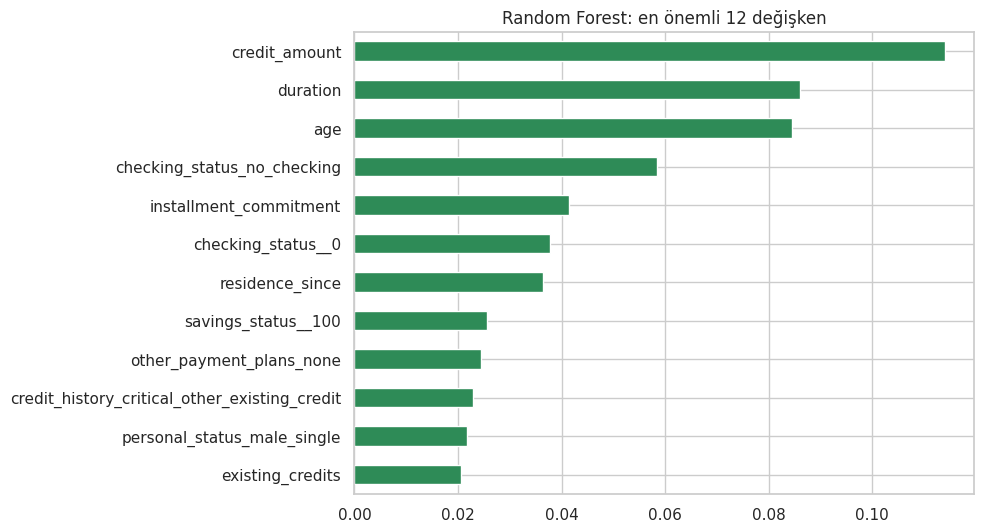

In [9]:
onem = pd.Series(modeller["Random Forest"].feature_importances_, index=X.columns).nlargest(12)
onem.sort_values().plot(kind="barh", figsize=(8, 6), color="seagreen")
plt.title("Random Forest: en önemli 12 değişken")
plt.show()

## 5. CatBoost'un farkı: kategorik değişkenleri kendisi işler
CatBoost'a one-hot yapmadan, kategorik sütunları olduğu gibi verip hangilerinin kategorik olduğunu söylememiz yeterli.
Aynı train/test ayrımını kullanmak için satırları index ile seçiyoruz.

In [10]:
X_ham = df.drop(columns="riskli").copy()
X_ham[kategorik] = X_ham[kategorik].astype(str)

cat_ham = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=SEED,
                             verbose=0, cat_features=kategorik)
cat_ham.fit(X_ham.loc[X_tr.index], y_tr)
auc_ham = roc_auc_score(y_te, cat_ham.predict_proba(X_ham.loc[X_te.index])[:, 1])

print(f"CatBoost (one-hot)       test AUC: {tablo.loc['CatBoost', 'test_auc']:.3f}")
print(f"CatBoost (ham kategorik) test AUC: {auc_ham:.3f}")

CatBoost (one-hot)       test AUC: 0.820
CatBoost (ham kategorik) test AUC: 0.802
